时间粒度归为小时

In [2]:
import pandas as pd
from pathlib import Path
import os
from tqdm import tqdm

# --- 1. 定义路径 ---

# 输入目录 (来自上一个单元格)
INPUT_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\02_data_collection_for_HF_simulation\01_collect_max_time_range_for_every_coin\data\every_icon_price_sequence")

# 你指定的新输出目录
OUTPUT_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\02_data_collection_for_HF_simulation\02_simulate_HF_for_every_sample\data\every_icon_price_sequence_in_eth")

ETH_FILE_NAME = "ETH_hourly_price_data.csv"

# --- 2. 确保输出目录存在 ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"输出目录已准备好: {OUTPUT_DIR}")

# --- 3. 加载并处理基准 ETH 价格 ---
eth_file_path = INPUT_DIR / ETH_FILE_NAME
if not eth_file_path.exists():
    print(f"严重错误：找不到基准 ETH 价格文件: {eth_file_path}")
    raise FileNotFoundError("ETH price file not found.")

print(f"正在加载基准 ETH 价格从: {eth_file_path}")
df_eth = pd.read_csv(eth_file_path)

# --- 关键修复 1：使用 format='ISO8601' 解决 ValueError ---
try:
    df_eth['datetime_utc'] = pd.to_datetime(df_eth['datetime_utc'], format='ISO8601')
except ValueError as e:
    print(f"错误：即使使用 'ISO8601' 也无法解析 ETH 时间戳: {e}")
    # (如果 'ISO8601' 失败，'mixed' 是最后的备用方案)
    # df_eth['datetime_utc'] = pd.to_datetime(df_eth['datetime_utc'], format='mixed')
    raise e

# --- 关键修复 2：按小时归并 (Floor & Aggregate) ---
df_eth['datetime_hourly'] = df_eth['datetime_utc'].dt.floor('H')
df_eth_hourly = df_eth.groupby('datetime_hourly').agg(
    price_eth_usd=('price_usd', 'mean')
).reset_index()

print(f"成功加载并按小时聚合了 {len(df_eth_hourly)} 条 ETH 价格记录。")


# --- 4. 遍历所有其他资产文件并转换 ---

# 筛选出资产文件（CSV 且不是 ETH 文件）
asset_files_to_process = [
    f for f in os.listdir(INPUT_DIR) 
    if f.endswith('.csv') and f != ETH_FILE_NAME
]

print(f"\n--- 找到 {len(asset_files_to_process)} 个资产文件需要转换为 ETH 计价 ---")

for filename in tqdm(asset_files_to_process, desc="转换资产价格为 ETH 计价"):
    asset_file_path = INPUT_DIR / filename
    asset_symbol = filename.split('_')[0]
    
    try:
        # 加载资产价格
        df_asset = pd.read_csv(asset_file_path)
        if df_asset.empty:
            tqdm.write(f"  -> 警告: {filename} 为空，已跳过。")
            continue
            
        # --- 关键修复 1：使用 format='ISO8601' ---
        df_asset['datetime_utc'] = pd.to_datetime(df_asset['datetime_utc'], format='ISO8601')
        
        # --- 关键修复 2：按小时归并 (Floor & Aggregate) ---
        df_asset['datetime_hourly'] = df_asset['datetime_utc'].dt.floor('H')
        df_asset_hourly = df_asset.groupby('datetime_hourly').agg(
            price_usd=('price_usd', 'mean')
        ).reset_index()

        # 按 'datetime_hourly' 列将资产与 ETH 合并
        df_merged = pd.merge(
            df_asset_hourly,
            df_eth_hourly[['datetime_hourly', 'price_eth_usd']],
            on='datetime_hourly',
            how='inner'
        )

        if df_merged.empty:
            tqdm.write(f"  -> 警告: {asset_symbol} 未能与 ETH 数据找到任何匹配的小时时间戳。")
            continue

        # --- 5. 执行计算 ---
        df_merged = df_merged[df_merged['price_eth_usd'] > 0]
        df_merged['price_in_eth'] = df_merged['price_usd'] / df_merged['price_eth_usd']
        
        # --- 6. 准备并保存新文件 ---
        # (重命名 'datetime_hourly' 为 'datetime_utc' 以保持一致性)
        df_output = df_merged[['datetime_hourly', 'price_in_eth']].copy()
        df_output = df_output.rename(columns={'datetime_hourly': 'datetime_utc'})
        
        # 转换回 ISO 字符串
        df_output['datetime_utc'] = df_output['datetime_utc'].apply(lambda x: x.isoformat())
        
        output_filename = f"{asset_symbol}_price_in_eth.csv"
        output_path = OUTPUT_DIR / output_filename
        df_output.to_csv(output_path, index=False, encoding='utf-8')
        
    except Exception as e:
        tqdm.write(f"  -> 错误: 处理 {filename} 时发生意外错误: {e}")

print(f"\n--- 全部完成 --- \n所有 ETH 计价的(每小时)价格序列文件已保存到: {OUTPUT_DIR}")

C:\Users\10158\AppData\Local\Temp\ipykernel_22964\3085824487.py:39: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_eth['datetime_hourly'] = df_eth['datetime_utc'].dt.floor('H')


输出目录已准备好: F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\02_data_collection_for_HF_simulation\02_simulate_HF_for_every_sample\data\every_icon_price_sequence_in_eth
正在加载基准 ETH 价格从: F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\02_data_collection_for_HF_simulation\01_collect_max_time_range_for_every_coin\data\every_icon_price_sequence\ETH_hourly_price_data.csv
成功加载并按小时聚合了 2160 条 ETH 价格记录。

--- 找到 10 个资产文件需要转换为 ETH 计价 ---


转换资产价格为 ETH 计价:   0%|          | 0/10 [00:00<?, ?it/s]C:\Users\10158\AppData\Local\Temp\ipykernel_22964\3085824487.py:72: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_asset['datetime_hourly'] = df_asset['datetime_utc'].dt.floor('H')
C:\Users\10158\AppData\Local\Temp\ipykernel_22964\3085824487.py:72: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_asset['datetime_hourly'] = df_asset['datetime_utc'].dt.floor('H')
C:\Users\10158\AppData\Local\Temp\ipykernel_22964\3085824487.py:72: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_asset['datetime_hourly'] = df_asset['datetime_utc'].dt.floor('H')
转换资产价格为 ETH 计价:  30%|███       | 3/10 [00:00<00:00, 20.64it/s]C:\Users\10158\AppData\Local\Temp\ipykernel_22964\3085824487.py:72: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_as


--- 全部完成 --- 
所有 ETH 计价的(每小时)价格序列文件已保存到: F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\02_data_collection_for_HF_simulation\02_simulate_HF_for_every_sample\data\every_icon_price_sequence_in_eth


--- 正在加载所有价格数据 ---
  -> 正在从 every_icon_price_sequence_in_eth 加载 10 个文件...
  -> 正在从 every_icon_price_sequence 加载 11 个文件...
数据加载完成。
--- 正在计算最小时间交集 ---
  -> 时间交集已确定为:
     开始 (UTC): 2025-08-01T14:09:59.770000+00:00
     结束 (UTC): 2025-10-30T13:00:19.538000+00:00

--- 正在生成图表 1 (ETH 计价) ---


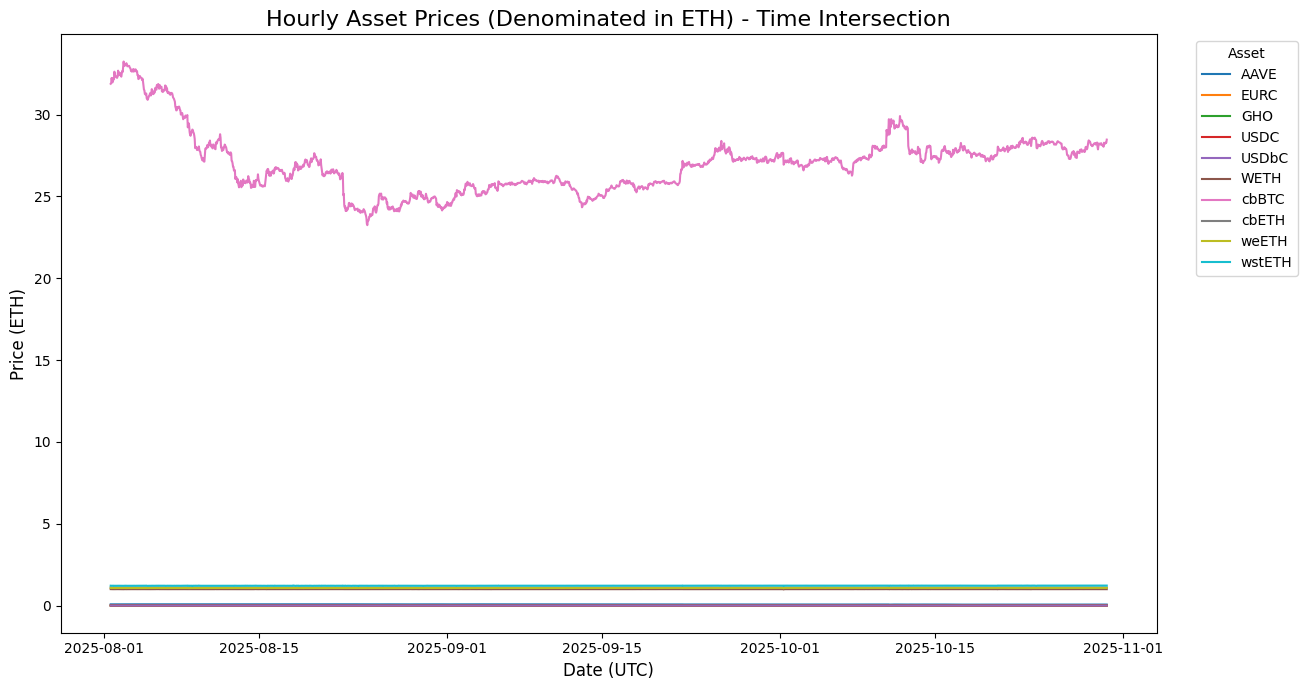


--- 第 2 部分：计算与 ETH 的价格比例 (是否为 1) ---
--- 正在分析已加载的 ETH 计价数据... ---
资产: AAVE   | 平均价格 (ETH): 0.066353 | 波动 (Std Dev): 0.005273
资产: EURC   | 平均价格 (ETH): 0.000277 | 波动 (Std Dev): 0.000020
资产: GHO    | 平均价格 (ETH): 0.000237 | 波动 (Std Dev): 0.000018
资产: USDC   | 平均价格 (ETH): 0.000237 | 波动 (Std Dev): 0.000018
资产: USDbC  | 平均价格 (ETH): 0.000237 | 波动 (Std Dev): 0.000018
资产: WETH   | 平均价格 (ETH): 1.000029 | 波动 (Std Dev): 0.001179
资产: cbBTC  | 平均价格 (ETH): 27.024972 | 波动 (Std Dev): 1.848252
资产: cbETH  | 平均价格 (ETH): 1.100329 | 波动 (Std Dev): 0.001832
资产: weETH  | 平均价格 (ETH): 1.074983 | 波动 (Std Dev): 0.003344
资产: wstETH | 平均价格 (ETH): 1.212091 | 波动 (Std Dev): 0.003948

--- 结论 ---
以下资产的平均价格在此时间交集内非常接近 1 (平均值 0.99-1.01, 波动 < 0.01):
  - WETH

--- 可视化和计算完成 ---


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm import tqdm

# --- 1. 定义路径 ---

# ETH 计价的价格 (用于图表 1)
ETH_PRICE_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\02_data_collection_for_HF_simulation\02_simulate_HF_for_every_sample\data\every_icon_price_sequence_in_eth")

# USD 计价的价格 (!! 仍需用于计算全局时间交集 !!)
USD_PRICE_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\02_data_collection_for_HF_simulation\01_collect_max_time_range_for_every_coin\data\every_icon_price_sequence")

# --- 2. 辅助函数：加载和准备数据 ---

def load_data_from_directory(directory, price_col_name, include_eth=False):
    """
    加载目录中的所有 CSV，解析时间，并将其设置为索引。
    返回一个字典，{symbol: DataFrame}
    """
    dataframes = {}
    
    # 筛选出要加载的文件
    files_to_load = [f for f in os.listdir(directory) if f.endswith('.csv')]
    if not include_eth:
        files_to_load = [f for f in files_to_load if not f.startswith("ETH_")]
    
    print(f"  -> 正在从 {directory.name} 加载 {len(files_to_load)} 个文件...")

    for filename in files_to_load:
        file_path = directory / filename
        symbol = filename.split('_')[0] # 例如 AAVE
        
        try:
            df = pd.read_csv(file_path)
            if df.empty:
                continue
                
            # 解析 datetime 并设置为索引
            df['datetime_utc'] = pd.to_datetime(df['datetime_utc'], format='ISO8601')
            df = df.set_index('datetime_utc')
            
            # 重命名列以便合并
            df = df.rename(columns={price_col_name: symbol})
            dataframes[symbol] = df[[symbol]]
            
        except Exception as e:
            print(f"    - 警告: 加载 {filename} 失败: {e}")
            
    return dataframes

# --- 3. 加载所有数据 ---
print("--- 正在加载所有价格数据 ---")
# 1. 加载 ETH 计价数据 (用于绘图)
eth_denom_dfs = load_data_from_directory(ETH_PRICE_DIR, 'price_in_eth', include_eth=False)
# 2. 加载 USD 计价数据 (用于计算全局时间交集)
usd_denom_dfs = load_data_from_directory(USD_PRICE_DIR, 'price_usd', include_eth=True)

if not eth_denom_dfs or not usd_denom_dfs:
    print("错误：未能加载足够的数据进行绘图。请检查 CSV 文件是否存在。")
else:
    print("数据加载完成。")

    # --- 4. 找到“最小时间交集” ---
    print("--- 正在计算最小时间交集 ---")
    all_start_times = []
    all_end_times = []
    
    # 检查并确保 DataFrame 不为空
    valid_dfs = [df for df in usd_denom_dfs.values() if not df.empty]
    
    if not valid_dfs:
         print("错误：所有加载的 DataFrame 均为空，无法计算时间交集。")
    else:
        for df in valid_dfs:
            all_start_times.append(df.index.min())
            all_end_times.append(df.index.max())

        intersection_start = max(all_start_times)
        intersection_end = min(all_end_times)

        print(f"  -> 时间交集已确定为:")
        print(f"     开始 (UTC): {intersection_start.isoformat()}")
        print(f"     结束 (UTC): {intersection_end.isoformat()}")

        if intersection_start >= intersection_end:
            print("错误：未找到重叠的时间交集。无法绘图。")
        else:
            # --- 5. 准备并绘制图表 1 (ETH 计价) ---
            print("\n--- 正在生成图表 1 (ETH 计价) ---")
            
            df_eth_wide = pd.concat([df for df in eth_denom_dfs.values() if not df.empty], axis=1, join='outer')
            df_eth_filtered = df_eth_wide.loc[intersection_start:intersection_end]
            
            # 转换为长格式
            df_eth_long = df_eth_filtered.melt(var_name='Asset', value_name='Price in ETH', ignore_index=False)
            
            # --- (!! 关键修复 !!) ---
            # 1. 将 'datetime_utc' 从索引重置为一列 (修复 ValueError)
            df_eth_long = df_eth_long.reset_index()
            
            plt.figure(figsize=(15, 7))
            # 2. x= 现在使用 'datetime_utc' *列*
            ax1 = sns.lineplot(
                data=df_eth_long,
                x='datetime_utc', # <-- (已修复)
                y='Price in ETH',
                hue='Asset',
                palette='tab10'
            )
            # --- (修复结束) ---
            
            ax1.set_title('Hourly Asset Prices (Denominated in ETH) - Time Intersection', fontsize=16)
            ax1.set_xlabel('Date (UTC)', fontsize=12)
            ax1.set_ylabel('Price (ETH)', fontsize=12)
            ax1.legend(title='Asset', bbox_to_anchor=(1.03, 1), loc='upper left')
            plt.tight_layout(rect=[0, 0, 0.88, 1]) # 为图例腾出空间
            plt.show()

            
            # --- 第 2 部分：计算与 ETH 比例为 1 的币 ---
            print("\n" + "="*50)
            print("--- 第 2 部分：计算与 ETH 的价格比例 (是否为 1) ---")
            print("--- 正在分析已加载的 ETH 计价数据... ---")
            
            ratio_one_coins = []
            
            # 我们重用已经加载的 `eth_denom_dfs` 字典
            for symbol, df in eth_denom_dfs.items():
                if df.empty:
                    continue
                
                # 筛选到我们图表使用的时间交集
                df_filtered = df.loc[intersection_start:intersection_end].dropna()
                
                if df_filtered.empty:
                    print(f"资产: {symbol:<6} | 在时间交集内无数据可分析。")
                    continue

                # 计算统计数据
                mean_price = df_filtered[symbol].mean()
                std_price = df_filtered[symbol].std()
                
                print(f"资产: {symbol:<6} | 平均价格 (ETH): {mean_price:.6f} | 波动 (Std Dev): {std_price:.6f}")
                
                # 定义 "接近 1" 的标准：
                # 平均值在 0.99 和 1.01 之间, 且标准差（波动性）小于 0.01 (1%)
                is_pegged = (mean_price > 0.99) and (mean_price < 1.01) and (std_price < 0.01)
                
                if is_pegged:
                    ratio_one_coins.append(symbol)

            print("\n--- 结论 ---")
            if not ratio_one_coins:
                print("未找到在此时间交集内与 ETH 严格 1:1 挂钩的资产。")
            else:
                print("以下资产的平均价格在此时间交集内非常接近 1 (平均值 0.99-1.01, 波动 < 0.01):")
                for coin in ratio_one_coins:
                    print(f"  - {coin}")

print("\n--- 可视化和计算完成 ---")

--- 正在加载所有 USD 价格数据 (包括 ETH) ---
  -> 正在从 every_icon_price_sequence 加载 11 个 USD 价格文件...
数据加载完成。
--- 正在计算最小时间交集 ---
  -> 时间交集已确定为:
     开始 (UTC): 2025-08-01T14:09:59.770000+00:00
     结束 (UTC): 2025-10-30T13:00:19.538000+00:00

--- 正在生成 USD 价格子图网格 ---


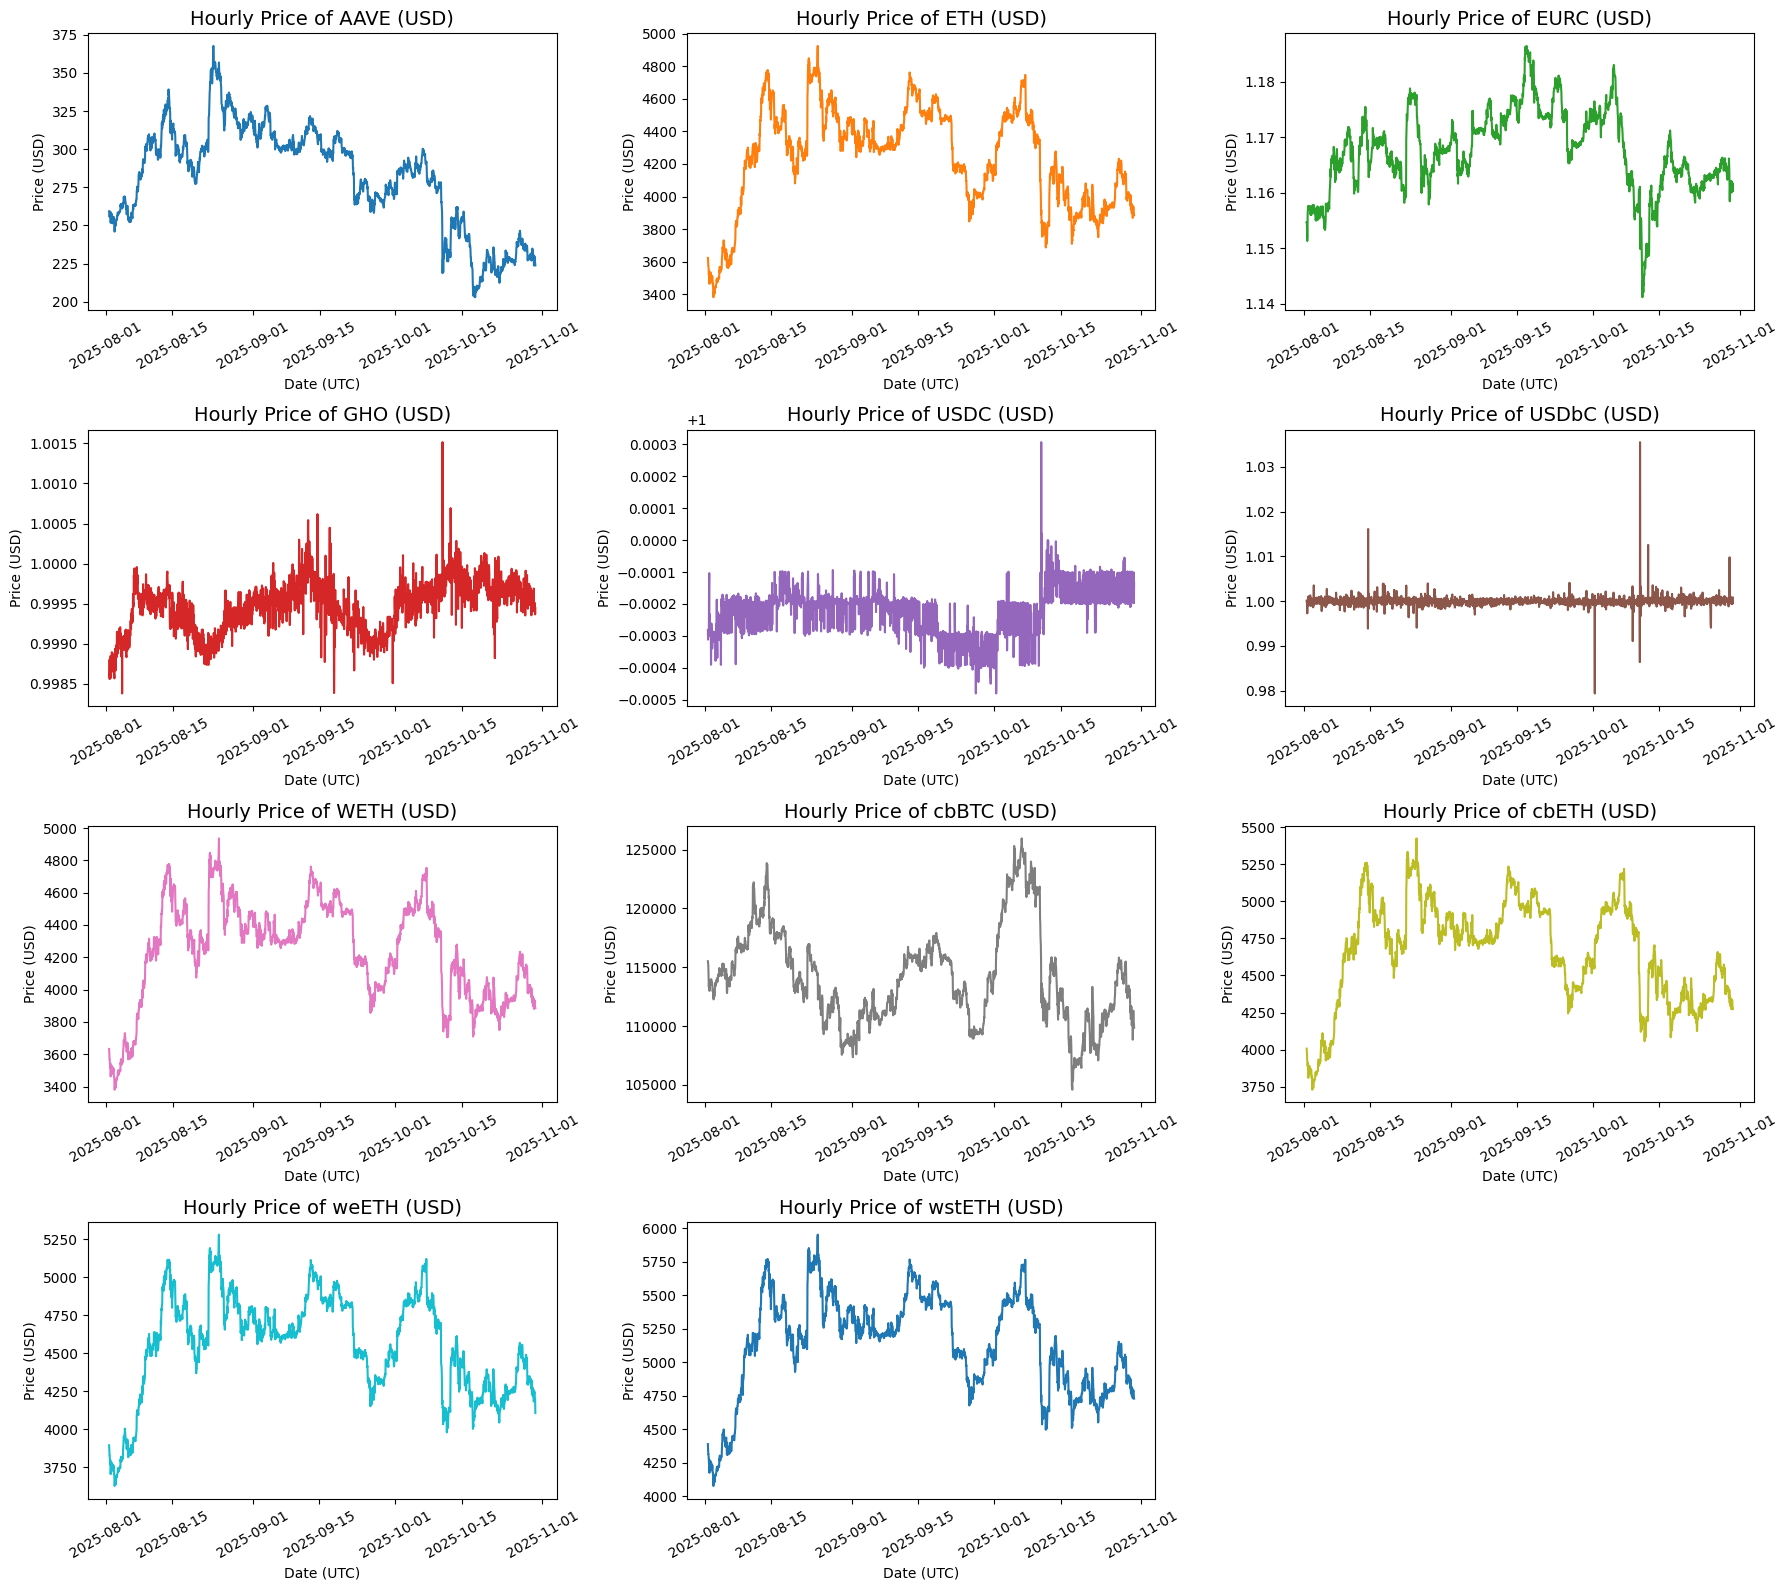


--- 可视化完成 ---


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os
import math
from tqdm import tqdm

# --- 1. 定义路径 ---

# USD 计价的价格 (用于图表 2)
USD_PRICE_DIR = Path(r"F:\Learning_journal_at_CUHK\FTEC5520_Appl Blockchain & Cryptocur\aave_data_collection\src\02_HF_simulation\02_data_collection_for_HF_simulation\01_collect_max_time_range_for_every_coin\data\every_icon_price_sequence")

# --- 2. 辅助函数：加载和准备数据 ---

def load_all_usd_data(directory, price_col_name="price_usd"):
    """
    加载目录中的所有 CSV，解析时间，并将其设置为索引。
    返回一个字典，{symbol: DataFrame}
    """
    dataframes = {}
    
    # 筛选出要加载的文件
    files_to_load = [f for f in os.listdir(directory) if f.endswith('.csv')]
    
    print(f"  -> 正在从 {directory.name} 加载 {len(files_to_load)} 个 USD 价格文件...")

    for filename in files_to_load:
        file_path = directory / filename
        symbol = filename.split('_')[0] # 例如 AAVE 或 ETH
        
        try:
            df = pd.read_csv(file_path)
            if df.empty:
                continue
                
            # 解析 datetime 并设置为索引
            df['datetime_utc'] = pd.to_datetime(df['datetime_utc'], format='ISO8601')
            df = df.set_index('datetime_utc')
            
            # 重命名列以便合并
            df = df.rename(columns={price_col_name: symbol})
            dataframes[symbol] = df[[symbol]]
            
        except Exception as e:
            print(f"    - 警告: 加载 {filename} 失败: {e}")
            
    return dataframes

# --- 3. 加载所有数据 ---
print("--- 正在加载所有 USD 价格数据 (包括 ETH) ---")
usd_denom_dfs = load_all_usd_data(USD_PRICE_DIR)

if not usd_denom_dfs:
    print("错误：未能加载足够的数据进行绘图。请检查 CSV 文件是否存在。")
else:
    print("数据加载完成。")

    # --- 4. 找到“最小时间交集” ---
    print("--- 正在计算最小时间交集 ---")
    all_start_times = []
    all_end_times = []
    
    # 检查并确保 DataFrame 不为空
    valid_dfs = [df for df in usd_denom_dfs.values() if not df.empty]
    
    if not valid_dfs:
         print("错误：所有加载的 DataFrame 均为空，无法计算时间交集。")
    else:
        for df in valid_dfs:
            all_start_times.append(df.index.min())
            all_end_times.append(df.index.max())

        intersection_start = max(all_start_times)
        intersection_end = min(all_end_times)

        print(f"  -> 时间交集已确定为:")
        print(f"     开始 (UTC): {intersection_start.isoformat()}")
        print(f"     结束 (UTC): {intersection_end.isoformat()}")

        if intersection_start >= intersection_end:
            print("错误：未找到重叠的时间交集。无法绘图。")
        else:
            # --- 5. 准备并绘制子图网格 ---
            print("\n--- 正在生成 USD 价格子图网格 ---")
            
            # 获取资产列表并排序，以确保绘图顺序一致
            asset_list = sorted(list(usd_denom_dfs.keys()))
            n_plots = len(asset_list)
            
            # 动态计算网格布局
            n_cols = 3 # 固定为 3 列
            n_rows = math.ceil(n_plots / n_cols) # 动态计算行数 (例如 11 / 3 = 4)
            
            # 创建一个足够大的画布
            fig, axes = plt.subplots(
                n_rows, 
                n_cols, 
                figsize=(18, n_rows * 4) # 宽度 18, 每行高度 4
            )
            
            # 获取一个颜色列表
            # 我们使用 'tab10' 循环，以防资产多于 10 个
            colors = sns.color_palette("tab10", n_colors=n_plots)
            
            # “展平” axes 数组 (从 2D [row, col] 变为 1D [i])以便于循环
            axes_flat = axes.flat
            
            # --- 6. 循环绘制每个子图 ---
            for i, asset_name in enumerate(asset_list):
                
                ax = axes_flat[i] # 获取当前子图
                color = colors[i]  # 获取当前颜色
                
                # 获取数据并筛选到时间交集
                df_asset = usd_denom_dfs[asset_name]
                df_filtered = df_asset.loc[intersection_start:intersection_end]
                
                # 在子图上绘图
                sns.lineplot(
                    data=df_filtered,
                    x=df_filtered.index,
                    y=asset_name, # y 轴是该资产的列
                    color=color,
                    ax=ax
                )
                
                # 设置子图的标题和标签
                ax.set_title(f"Hourly Price of {asset_name} (USD)", fontsize=14)
                ax.set_xlabel("Date (UTC)", fontsize=10)
                ax.set_ylabel("Price (USD)", fontsize=10)
                
                # 自动格式化日期标签
                ax.tick_params(axis='x', rotation=30)

            # --- 7. 隐藏多余的空子图 ---
            # (例如, 4x3=12 个图, 但我们只有 11 个资产, 需隐藏第 12 个)
            n_total_plots = n_rows * n_cols
            for i in range(n_plots, n_total_plots):
                axes_flat[i].set_visible(False)
            
            plt.tight_layout() # 自动调整布局防止重叠
            plt.show()

print("\n--- 可视化完成 ---")